# Infer

This notebook is notebook-driven on purpose: it shows the effective config at launch time, keeps `control`, `guided`, and `feedback` in separate passes, prints progress as runs happen, and persists all infer artifacts immediately.

In [5]:
import concurrent.futures
import os
from datetime import UTC, datetime
from pathlib import Path

import pandas as pd
from IPython.display import JSON, SVG, display

from src.lib.analyze_pipeline import (
    collect_infer_snapshot_metrics,
    discover_infer_artifacts,
    render_model_snapshot_svg,
)
from src.lib.infer_pipeline import (
    SUPPORTED_SCENARIOS,
    build_config_snapshot,
    build_run_paths,
    find_repo_root,
    load_feedback_prompt_bundle,
    load_prompt_bundle,
    load_runtime_config,
    load_source_matrix,
    parse_optional_int,
    process_feedback_run,
    process_run,
    rebuild_index,
    select_scenario_rows,
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

repo_root = find_repo_root(Path.cwd())
runtime_config = load_runtime_config(repo_root)
source_matrix = load_source_matrix(repo_root)
max_new_requests = parse_optional_int(os.getenv("INFER_MAX_NEW_REQUESTS"))
remaining_new_requests = max_new_requests
infer_max_workers: int = parse_optional_int(os.getenv("INFER_MAX_WORKERS")) # type: ignore
if infer_max_workers is None:
    infer_max_workers = 8
infer_max_workers = max(1, infer_max_workers)

prompt_bundles = {
    scenario: load_prompt_bundle(repo_root, scenario)
    for scenario in SUPPORTED_SCENARIOS
}
guided_prompt_bundle = prompt_bundles["guided"]
feedback_prompt_bundle = load_feedback_prompt_bundle(repo_root)
scenario_rows = {
    scenario: select_scenario_rows(source_matrix, scenario)
    for scenario in SUPPORTED_SCENARIOS
}

all_summaries = []
latest_index_df = rebuild_index(repo_root)


def run_is_cached(row: dict, run_number: int) -> bool:
    paths = build_run_paths(repo_root, row, run_number)
    return paths.final_cs_path.exists() and paths.metadata_path.exists()


def build_scenario_work_items(scenario: str) -> list[tuple[int, dict, int, bool]]:
    rows = scenario_rows[scenario]
    budget_slots = remaining_new_requests
    work_items = []
    work_index = 0
    for row in rows:
        for run_number in range(1, runtime_config.runs + 1):
            work_index += 1
            should_execute = True
            if not run_is_cached(row, run_number) and budget_slots is not None:
                should_execute = budget_slots > 0
                if should_execute:
                    budget_slots -= 1
            work_items.append((work_index, row, run_number, should_execute))
    return work_items


def process_scenario_work_item(
    scenario: str,
    work_index: int,
    row: dict,
    run_number: int,
    should_execute: bool,
) -> tuple[int, dict]:
    if scenario == "feedback":
        summary, _record = process_feedback_run(
            repo_root=repo_root,
            row=row,
            run_number=run_number,
            runtime_config=runtime_config,
            guided_prompt_bundle=guided_prompt_bundle,
            feedback_prompt_bundle=feedback_prompt_bundle,
            should_execute=should_execute,
        )
    else:
        summary, _record = process_run(
            repo_root=repo_root,
            row=row,
            run_number=run_number,
            runtime_config=runtime_config,
            prompt_bundle=prompt_bundles[scenario],
            should_execute=should_execute,
        )
    return work_index, summary


def print_summary_progress(
    scenario: str,
    completed_steps: int,
    total_steps: int,
    summary: dict,
) -> None:
    print(
        f"[{scenario} {completed_steps}/{total_steps}] {summary['status'].upper()} | "
        f"{summary['document']} | {summary['model']} | run {summary['run']}",
        flush=True,
    )
    if scenario == "feedback":
        print(f"  step0: {summary['step0_cs_path']}", flush=True)
        print(f"  notes: {summary['feedback_md_path']}", flush=True)
    print(f"  final: {summary['final_cs_path']}", flush=True)
    print(f"  meta:  {summary['metadata_path']}", flush=True)
    if "error" in summary:
        print(f"  error: {summary['error']}", flush=True)


def run_scenario_pass(scenario: str) -> pd.DataFrame:
    global remaining_new_requests, latest_index_df

    rows = scenario_rows[scenario]
    total_steps = len(rows) * runtime_config.runs
    worker_count = min(infer_max_workers, total_steps) if total_steps else 1
    scenario_results = []
    completed_steps = 0

    print(f"Started {scenario} at {datetime.now(UTC).isoformat()}", flush=True)
    print(
        f"Rows: {len(rows)} | Runs per row: {runtime_config.runs} | "
        f"Total steps: {total_steps}",
        flush=True,
    )
    print(f"Infer workers: {worker_count}", flush=True)
    print(f"Remaining new-request budget before pass: {remaining_new_requests}", flush=True)

    work_items = build_scenario_work_items(scenario)
    if work_items:
        with concurrent.futures.ThreadPoolExecutor(max_workers=worker_count) as executor:
            future_to_work = {
                executor.submit(process_scenario_work_item, scenario, *work_item): work_item
                for work_item in work_items
            }
            for future in concurrent.futures.as_completed(future_to_work):
                work_index, summary = future.result()
                completed_steps += 1
                scenario_results.append((work_index, summary))
                all_summaries.append(summary)
                print_summary_progress(scenario, completed_steps, total_steps, summary)

                if summary["status"] == "executed" and remaining_new_requests is not None:
                    remaining_new_requests -= 1
                    print(
                        f"  remaining new-request budget: {remaining_new_requests}",
                        flush=True,
                    )

    scenario_summaries = [
        summary
        for _work_index, summary in sorted(scenario_results, key=lambda item: item[0])
    ]
    latest_index_df = rebuild_index(repo_root)
    scenario_df = pd.DataFrame(scenario_summaries)

    if not scenario_df.empty:
        # display(scenario_df)
        display(scenario_df.groupby("status").size().to_frame("count").reset_index())
    else:
        print(f"No rows were produced for scenario {scenario}.")

    return scenario_df

In [6]:
config_snapshot = build_config_snapshot(
    repo_root=repo_root,
    runtime_config=runtime_config,
    source_matrix=source_matrix,
    max_new_requests=max_new_requests,
)
config_snapshot["infer_max_workers"] = infer_max_workers

display(JSON(config_snapshot, expanded=True))
display(
    pd.DataFrame(
        [
            {
                "scenario": scenario,
                "rows": len(rows),
                "runs": runtime_config.runs,
                "infer_workers": min(infer_max_workers, len(rows) * runtime_config.runs),
                "planned_steps": len(rows) * runtime_config.runs,
            }
            for scenario, rows in scenario_rows.items()
        ]
    )
)

if latest_index_df.empty:
    print("No completed infer artifacts exist yet.")
else:
    display(latest_index_df[["scenario", "model", "document", "run", "final_cs_path"]].head())
    display(latest_index_df[["scenario", "model", "document", "run", "final_cs_path"]].shape)

<IPython.core.display.JSON object>

,scenario,rows,runs,infer_workers,planned_steps
0,control,192,5,8,960
1,guided,192,5,8,960
2,feedback,192,5,8,960


,scenario,model,document,run,final_cs_path
0,control,anthropic/claude-haiku-4.5,RFC_5789_patch_method_for_http.txt,1,artifacts/infer/RFC_5789_patch_method_for_http/control/anthropic-claude-haiku-4-5/run1/final.cs
1,control,anthropic/claude-haiku-4.5,RFC_5789_patch_method_for_http.txt,2,artifacts/infer/RFC_5789_patch_method_for_http/control/anthropic-claude-haiku-4-5/run2/final.cs
2,control,anthropic/claude-haiku-4.5,RFC_5789_patch_method_for_http.txt,3,artifacts/infer/RFC_5789_patch_method_for_http/control/anthropic-claude-haiku-4-5/run3/final.cs
3,control,anthropic/claude-haiku-4.5,RFC_5789_patch_method_for_http.txt,4,artifacts/infer/RFC_5789_patch_method_for_http/control/anthropic-claude-haiku-4-5/run4/final.cs
4,control,anthropic/claude-haiku-4.5,RFC_5789_patch_method_for_http.txt,5,artifacts/infer/RFC_5789_patch_method_for_http/control/anthropic-claude-haiku-4-5/run5/final.cs


(958, 5)

In [7]:
control_summary = run_scenario_pass("control")

Started control at 2026-05-15T15:21:41.999751+00:00
Rows: 192 | Runs per row: 5 | Total steps: 960
Infer workers: 8
Remaining new-request budget before pass: None
[control 1/960] CACHED | RFC_6585_additional_http_status_codes.txt | anthropic/claude-haiku-4.5 | run 2
  final: artifacts/infer/RFC_6585_additional_http_status_codes/control/anthropic-claude-haiku-4-5/run2/final.cs
  meta:  artifacts/infer/RFC_6585_additional_http_status_codes/control/anthropic-claude-haiku-4-5/run2/record.json
[control 2/960] CACHED | RFC_5789_patch_method_for_http.txt | anthropic/claude-haiku-4.5 | run 2
  final: artifacts/infer/RFC_5789_patch_method_for_http/control/anthropic-claude-haiku-4-5/run2/final.cs
  meta:  artifacts/infer/RFC_5789_patch_method_for_http/control/anthropic-claude-haiku-4-5/run2/record.json
[control 3/960] CACHED | RFC_5789_patch_method_for_http.txt | anthropic/claude-haiku-4.5 | run 5
  final: artifacts/infer/RFC_5789_patch_method_for_http/control/anthropic-claude-haiku-4-5/run5/fin

,status,count
0,cached,958
1,executed,2


In [9]:
guided_summary = run_scenario_pass("guided")

Started guided at 2026-05-15T16:21:49.914522+00:00
Rows: 192 | Runs per row: 5 | Total steps: 960
Infer workers: 8
Remaining new-request budget before pass: None
[guided 1/960] CACHED | RFC_6585_additional_http_status_codes.txt | anthropic/claude-haiku-4.5 | run 2
  final: artifacts/infer/RFC_6585_additional_http_status_codes/guided/anthropic-claude-haiku-4-5/run2/final.cs
  meta:  artifacts/infer/RFC_6585_additional_http_status_codes/guided/anthropic-claude-haiku-4-5/run2/record.json
[guided 2/960] CACHED | RFC_6750_oauth_2_0_bearer_token_usage.txt | anthropic/claude-haiku-4.5 | run 1
  final: artifacts/infer/RFC_6750_oauth_2_0_bearer_token_usage/guided/anthropic-claude-haiku-4-5/run1/final.cs
  meta:  artifacts/infer/RFC_6750_oauth_2_0_bearer_token_usage/guided/anthropic-claude-haiku-4-5/run1/record.json
[guided 3/960] CACHED | RFC_6750_oauth_2_0_bearer_token_usage.txt | anthropic/claude-haiku-4.5 | run 2
  final: artifacts/infer/RFC_6750_oauth_2_0_bearer_token_usage/guided/anthropic

,status,count
0,cached,945
1,executed,15


In [11]:
feedback_summary = run_scenario_pass("feedback")

Started feedback at 2026-05-15T17:47:18.646016+00:00
Rows: 192 | Runs per row: 5 | Total steps: 960
Infer workers: 8
Remaining new-request budget before pass: None
[feedback 1/960] CACHED | RFC_6585_additional_http_status_codes.txt | anthropic/claude-haiku-4.5 | run 2
  step0: artifacts/infer/RFC_6585_additional_http_status_codes/feedback/anthropic-claude-haiku-4-5/run2/step-0.cs
  notes: artifacts/infer/RFC_6585_additional_http_status_codes/feedback/anthropic-claude-haiku-4-5/run2/feedback.md
  final: artifacts/infer/RFC_6585_additional_http_status_codes/feedback/anthropic-claude-haiku-4-5/run2/final.cs
  meta:  artifacts/infer/RFC_6585_additional_http_status_codes/feedback/anthropic-claude-haiku-4-5/run2/record.json
[feedback 2/960] CACHED | RFC_5789_patch_method_for_http.txt | anthropic/claude-haiku-4.5 | run 4
  step0: artifacts/infer/RFC_5789_patch_method_for_http/feedback/anthropic-claude-haiku-4-5/run4/step-0.cs
  notes: artifacts/infer/RFC_5789_patch_method_for_http/feedback/an

,status,count
0,cached,934
1,executed,26


,document_stem,scenario,model,run,defined_type_count,line_count,parse_error_count
0,RFC_5789_patch_method_for_http,control,anthropic/claude-haiku-4.5,1,12,139,0
1,RFC_5789_patch_method_for_http,control,anthropic/claude-haiku-4.5,2,12,139,0
2,RFC_5789_patch_method_for_http,control,anthropic/claude-haiku-4.5,3,12,145,0
3,RFC_5789_patch_method_for_http,control,anthropic/claude-haiku-4.5,4,12,139,0
4,RFC_5789_patch_method_for_http,control,anthropic/claude-haiku-4.5,5,12,131,0


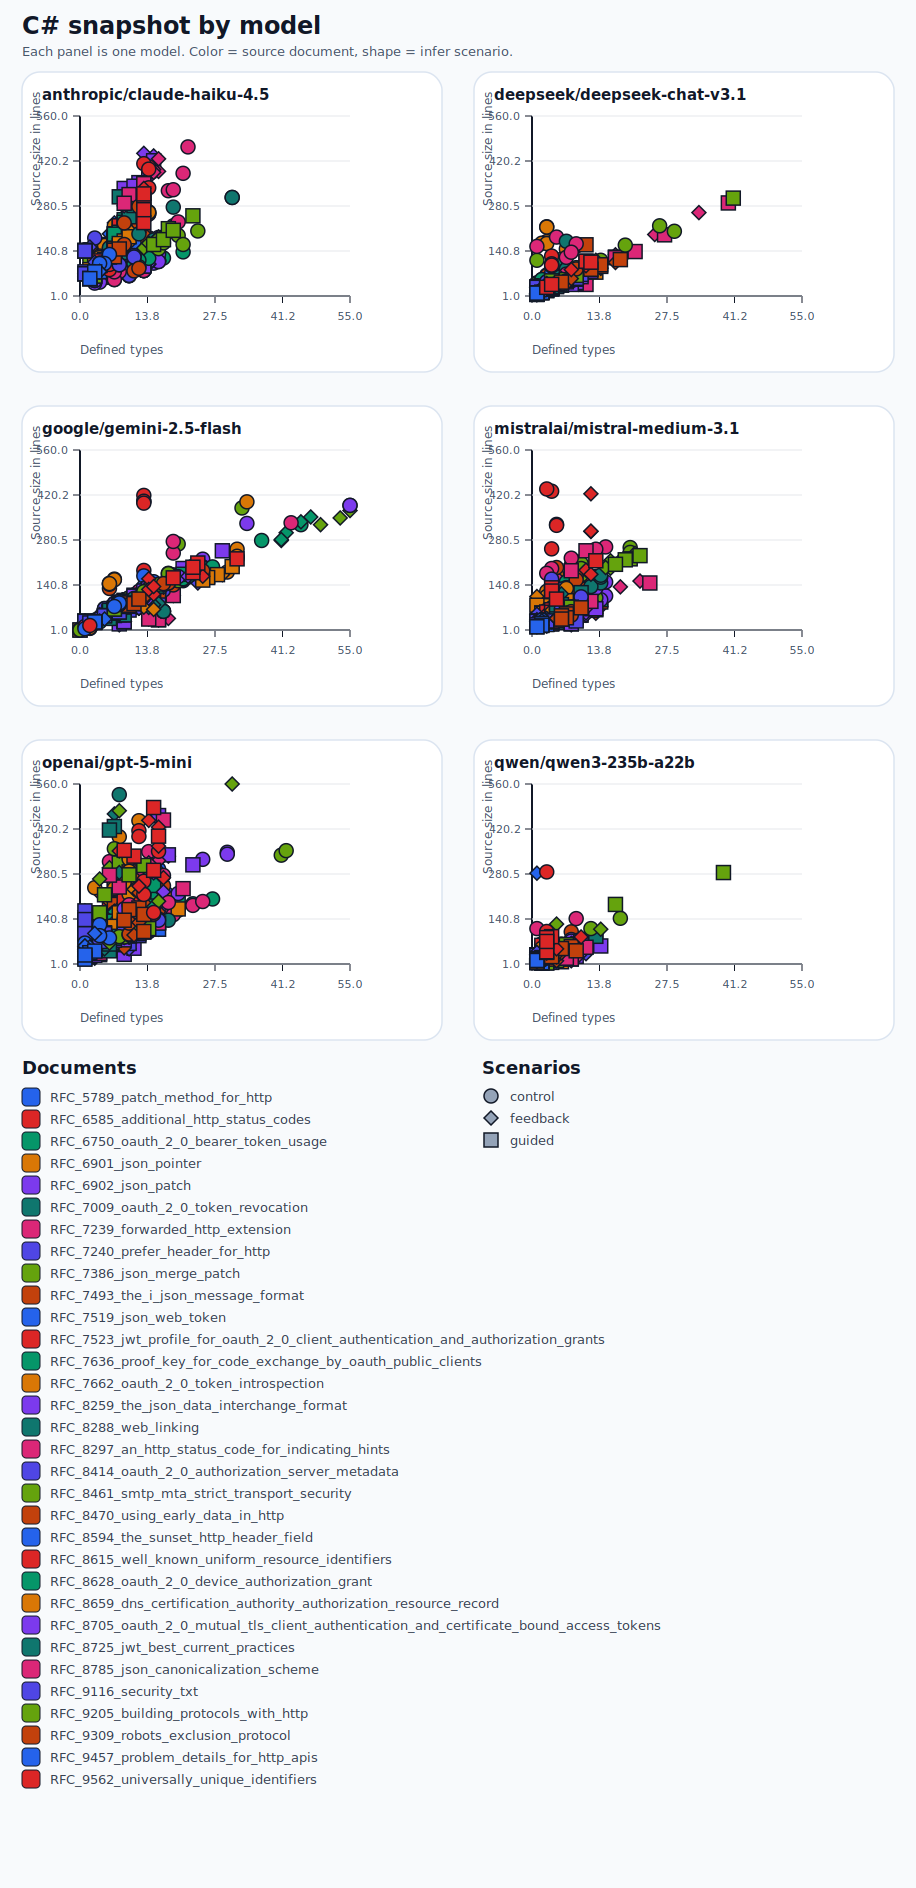

In [13]:
snapshot_artifact_df = discover_infer_artifacts(repo_root)
if snapshot_artifact_df.empty:
    print("No final.cs files available for the C# snapshot plot.")
else:
    snapshot_metrics_df = collect_infer_snapshot_metrics(repo_root, snapshot_artifact_df)
    display(snapshot_metrics_df[[
        "document_stem",
        "scenario",
        "model",
        "run",
        "defined_type_count",
        "line_count",
        "parse_error_count",
    ]].head())
    display(SVG(render_model_snapshot_svg(snapshot_metrics_df)))